Creates the flowchart used in my GRFP research proposal

Illustrates the current B12 state of the art then the two new major improvements, Himansh's Nbody ICs and Ethan's SMUGGLE run, and then the goal which is my work

This is a one off piece of code that isn't intended for future use which would require implementation in amms-core plotting and version stamping

This is also written to be run locally and is missing the more generic codes. This is purely just stitching together premade plots

In [63]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle

import textwrap

FIG_DIR = Path("/home/zvladimir/lmcsmcmw/figures")

In [74]:
def draw_panel(ax, spec, caption_width=60):
    if spec["path"] is not None and Path(spec["path"]).exists():
        ax.imshow(plt.imread(spec["path"]), cmap="gray")
        # ax.add_patch(Rectangle((0,0), 1, 1, transform=ax.transAxes, fill=False, edgecolor="black", linewidth=1.2))
    else:
        ax.add_patch(Rectangle((0.03, 0.03), 0.94, 0.94, fill=False, linestyle="--", linewidth=1.5, transform=ax.transAxes))
        ax.text(0.5, 0.5, "placeholder", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(spec["title"], fontsize=10)
    wrapped = textwrap.fill(spec["caption"], width=caption_width)
    ax.set_xlabel(wrapped, fontsize=8, style="italic")

In [65]:
PANELS = {
    "baseline": dict(
        path=FIG_DIR / "sfr_slice_5.png",
        title="Current state of the art",
        caption="",
    ),
    "nbody": dict(
        path=FIG_DIR / "clouds_ra_dec_simulated.jpg",
        title="Demonstrated: higher-res N-body ICs",
        caption=""
    ),
    "ism": dict(
        path="/home/zvladimir/lmcsmcmw/figures/jahn2023_smuggle-1.png",
        title="Demonstrated: SMUGGLE ISM model",
        caption="",
    ),
    "goal": dict(
        path="/home/zvladimir/lmcsmcmw/figures/mazzi2021_sfr_new.png",
        title="Produce: SFR maps matching observations",
        caption="",
    ),
}

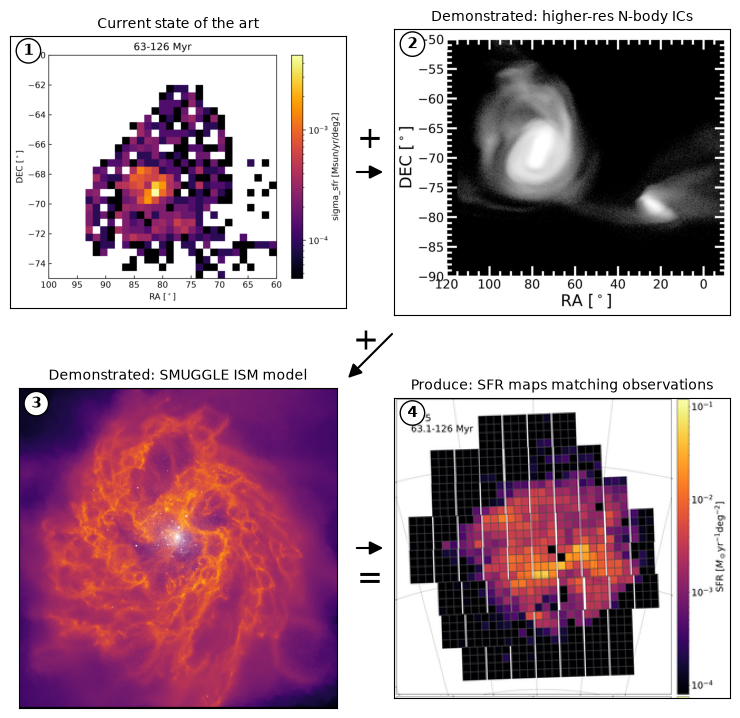

In [ ]:
fig = plt.figure(figsize=(8, 8))

# 2x2 grid, roughly equal panels now that A and D are single-panel too
ax_tl = fig.add_axes([0.05, 0.55, 0.42, 0.40])  # baseline
ax_tr = fig.add_axes([0.53, 0.55, 0.42, 0.40])  # nbody
ax_bl = fig.add_axes([0.05, 0.08, 0.42, 0.40])  # ism
ax_br = fig.add_axes([0.53, 0.08, 0.42, 0.40])  # goal

panel_axes = [(ax_tl, "baseline", "1"), (ax_tr, "nbody", "2"),
              (ax_bl, "ism", "3"), (ax_br, "goal", "4")]

for ax, key, num in panel_axes:
    draw_panel(ax, PANELS[key])
    ax.text(0.04, 0.975, num, transform=ax.transAxes, ha="left", va="top",
             fontsize=11, fontweight="bold",
             bbox=dict(boxstyle="circle", facecolor="white", edgecolor="black"))

arrow_kw = dict(arrowstyle="-|>", mutation_scale=20, linewidth=1.5, color="black",
                 transform=fig.transFigure)

# 1 -> 2: baseline -> nbody (top row, straight)
fig.patches.append(FancyArrowPatch((0.48, 0.75), (0.52, 0.75), **arrow_kw))
fig.text(0.50, 0.79, "+", fontsize=22, ha="center", va="center")

# 2 -> 3: nbody -> ism (diagonal, the middle step)
fig.patches.append(FancyArrowPatch((0.53, 0.55), (0.47, 0.49), **arrow_kw))
fig.text(0.495, 0.538, "+", fontsize=22, ha="center", va="center")

# 3 -> 4: ism -> goal (bottom row, straight)
fig.patches.append(FancyArrowPatch((0.48, 0.28), (0.52, 0.28), **arrow_kw))
fig.text(0.50, 0.24, "=", fontsize=22, ha="center", va="center")

fig.savefig(FIG_DIR / "grfp_flowchart_box_draft.pdf")


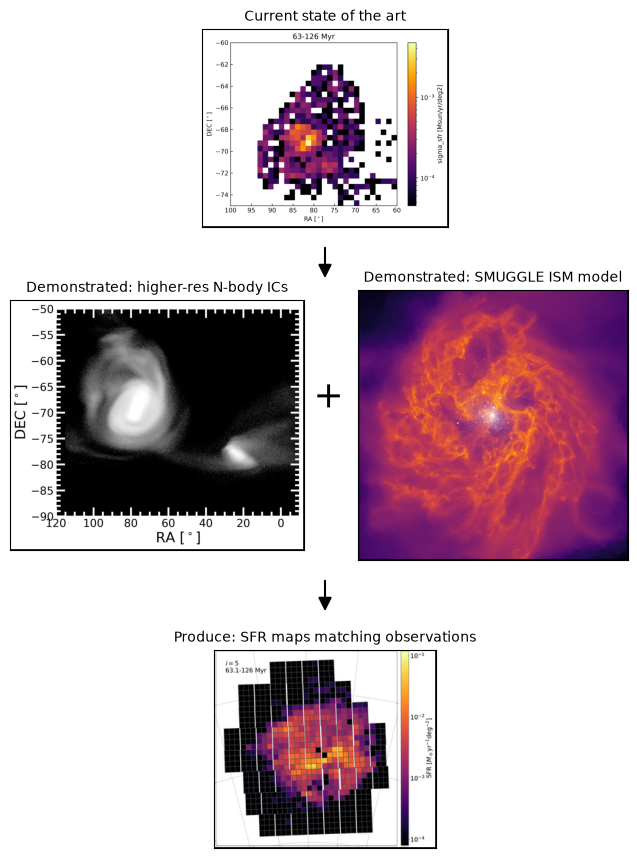

In [67]:
fig = plt.figure(figsize=(7, 9))

# top: baseline, full width, short (matches the wide row-of-panels shape)
ax_a    = fig.add_axes([0.05, 0.74, 0.90, 0.22])
# middle: nbody + ism side by side (still roughly square images)
ax_b    = fig.add_axes([0.05, 0.37, 0.42, 0.30])
ax_c    = fig.add_axes([0.53, 0.37, 0.42, 0.30])
# bottom: goal, full width, short
ax_goal = fig.add_axes([0.05, 0.05, 0.90, 0.22])

for ax, key in [(ax_a, "baseline"), (ax_b, "nbody"), (ax_c, "ism"), (ax_goal, "goal")]:
    draw_panel(ax, PANELS[key])

fig.text(0.505, 0.55, "+", fontsize=26, ha="center", va="center")

arrow_kw = dict(arrowstyle="-|>", mutation_scale=20, linewidth=1.5, color="black", transform=fig.transFigure)

fig.patches.append(FancyArrowPatch((0.50, 0.72), (0.50, 0.68), **arrow_kw))
fig.patches.append(FancyArrowPatch((0.50, 0.35), (0.50, 0.31), **arrow_kw))

fig.savefig(FIG_DIR / "grfp_flowchart_vert_draft.png", dpi=300)